# Tidy Data Project: Federal R&D Budget Data
### Project Overview

This project is meant to demonstrate principles of tidy data, such that:

1. Each Variable is in its own column.
2. Each observation forms its own row.
3. Each type of observational unit forms its own table.

The data used for this project contains budgets for 14 U.S. federal agencies from 1976 until 2017, as well as national GDP. 

### 1. Loading in Data and Libraries

In [1]:
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import seaborn as sns  # For easy dataset loading and visualizations
import matplotlib.pyplot as plt  # For plotting

In [ ]:
#Loading in the data... 
df = pd.read_csv("data/fed_rd_year&gdp.csv")


In [4]:
#inspecting data frame structure
df.head()

,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08,9.450000e+08,8.290000e+08,6.930000e+08,7.000000e+08,7.550000e+08,...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10,3.700500e+10,4.173700e+10,4.689300e+10,5.100800e+10,5.813900e+10,...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,1.088200e+10,1.374100e+10,1.566300e+10,1.561200e+10,1.522600e+10,1.479800e+10,1.216000e+10,1.112900e+10,1.173100e+10,...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,1.142000e+09,1.095000e+09,1.156000e+09,1.004000e+09,1.048000e+09,9.780000e+08,7.020000e+08,8.000000e+08,1.018000e+09,...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


#### Observing the data, it is clear that the variables in this dataset are 
    1. Department
    2. Year
    3. GDP
    4. R&D Spending 
#### Thus, these four variables should form the 4 columns of the cleaned dataset, in accordance with the principles of tidy data. 

## 1. Cleaning the Data to create 4 columns of department, year, GDP, and r&d spending

In [17]:
#Using pd.melt, make year and GDP (which were initially on the top row) into its own column
tidy_df = df.melt(
    id_vars="department",
    var_name="year_gdp",
    value_name="R&D_Spending"
)
#Heading the data, we now have 3 columns: department, year/GDP, and r&d spending
tidy_df.head()

,department,year_gdp,R&D_Spending
0,DHS,1976_gdp1790000000000.0,NaN
1,DOC,1976_gdp1790000000000.0,8.190000e+08
2,DOD,1976_gdp1790000000000.0,3.569600e+10
3,DOE,1976_gdp1790000000000.0,1.088200e+10
4,DOT,1976_gdp1790000000000.0,1.142000e+09


In [22]:
#This next step splits the combined column of year_gdp into seperate columns for year and GDP
tidy_df[["Year", "GDP"]] = tidy_df["year_gdp"].str.split("_gdp", expand=True)

#After creating 2 new columns, this drops the now useless year_gdp column
tidy_df = tidy_df.drop(columns="year_gdp")

#Heading the data, we can see that seperate columns for Year and GDP were created
tidy_df.head(20)


,department,R&D_Spending,Year,GDP
0,DHS,NaN,1976,1790000000000.0
1,DOC,8.190000e+08,1976,1790000000000.0
2,DOD,3.569600e+10,1976,1790000000000.0
3,DOE,1.088200e+10,1976,1790000000000.0
4,DOT,1.142000e+09,1976,1790000000000.0
5,EPA,9.680000e+08,1976,1790000000000.0
6,HHS,9.226000e+09,1976,1790000000000.0
7,Interior,1.152000e+09,1976,1790000000000.0
8,NASA,1.251300e+10,1976,1790000000000.0
9,NIH,8.025000e+09,1976,1790000000000.0


Now that the data is in its proper form, I will handle the NAs in the data

In [ ]:
#Checking for NAs
tidy_df[tidy_df["R&D_Spending"].isna()]["department"].unique()

#Looking at the data, I see that the only column with NAs is DHS. This line of code confirms this

array(['DHS'], dtype=object)

DHS was not created until 2002, so it got $0 of spending every year before. Hence, I will replace NA values with 0. 

In [25]:
#Replacing all NAs with 0
tidy_df["R&D_Spending"] = tidy_df["R&D_Spending"].fillna(0)

tidy_df.head()

,department,R&D_Spending,Year,GDP
0,DHS,0.000000e+00,1976,1790000000000.0
1,DOC,8.190000e+08,1976,1790000000000.0
2,DOD,3.569600e+10,1976,1790000000000.0
3,DOE,1.088200e+10,1976,1790000000000.0
4,DOT,1.142000e+09,1976,1790000000000.0


Next, I will make sure that all data is in the correct form

In [ ]:
#Checking data types
tidy_df.dtypes


department       object
R&D_Spending    float64
Year             object
GDP              object
dtype: object

In [27]:
#R&D Spending, Year, and GDP should all be numeric variables, but currently are not.
#This ensures that year is an integer, and GDP and R&D Spending are floats
tidy_df["Year"] = tidy_df["Year"].astype(int)
tidy_df["GDP"] = tidy_df["GDP"].astype(float)
tidy_df["R&D_Spending"] = pd.to_numeric(tidy_df["R&D_Spending"], errors="coerce")

In [28]:
#2 more changes for aesthetic purposes

#1. Renaming "department" to "Department"
tidy_df = tidy_df.rename(columns={"department": "Department"})

#2. Reordering the columns to department-->year-->GDP-->R&D spending
tidy_df = tidy_df[["Department", "Year", "GDP", "R&D_Spending"]]

tidy_df.head()

,Department,Year,GDP,R&D_Spending
0,DHS,1976,1.790000e+12,0.000000e+00
1,DOC,1976,1.790000e+12,8.190000e+08
2,DOD,1976,1.790000e+12,3.569600e+10
3,DOE,1976,1.790000e+12,1.088200e+10
4,DOT,1976,1.790000e+12,1.142000e+09


## 2. Visualizing the Cleaned Data

#### Visualization 1: Department Spending over time

This first plot is helpful in viusalizing which departments have had the most spending over time. Though most department spendings bunch towards the bottom, the outliers in this graph are helpful for visualizing which departments get prioritized in spending. 

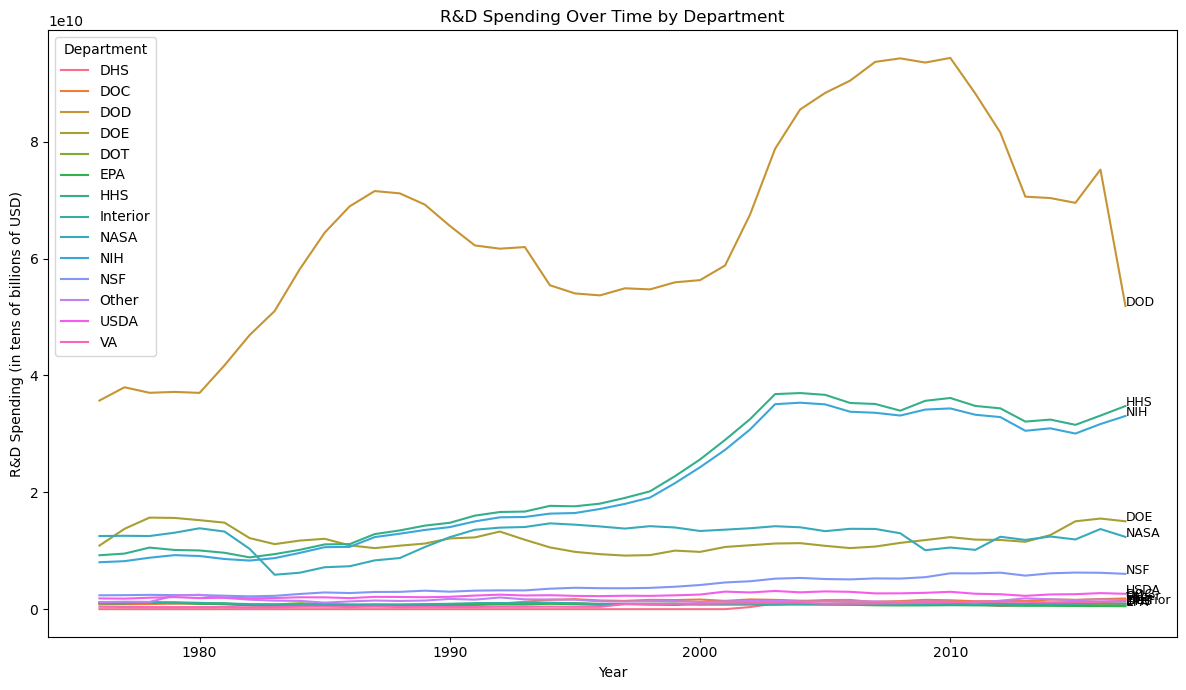

In [33]:
#Plotting... 
plt.figure(figsize=(12,7))

#Plotting year on x-axis, R&D Spending on the y-axis, and splitting based on depatment
ax = sns.lineplot(
    data=tidy_df,
    x="Year",
    y="R&D_Spending",
    hue="Department"
)

#Splitting into distinct departments
departments = tidy_df["Department"].unique()

#Labeling each line for greater Clarity
for dept in departments:
    dept_data = tidy_df[tidy_df["Department"] == dept]
    
    plt.text(
        dept_data["Year"].max(),
        dept_data["R&D_Spending"].iloc[-1],
        dept,
        fontsize=9
    )

#Labeling and displaying the plot
plt.title("R&D Spending Over Time by Department")
plt.xlabel("Year")
plt.ylabel("R&D Spending (in tens of billions of USD)")
plt.tight_layout()
plt.show()

#### Visualization 2: Department of Defense spending as a percentage of GDP over time

From the previous graph, it is clear that the DOD contains the majority of federal spending. Not to mention, defense spending is always relevant in debates over how the federal government allocates its resources. This graph shows how DOD spending has changed over time as a percentage of GDP.

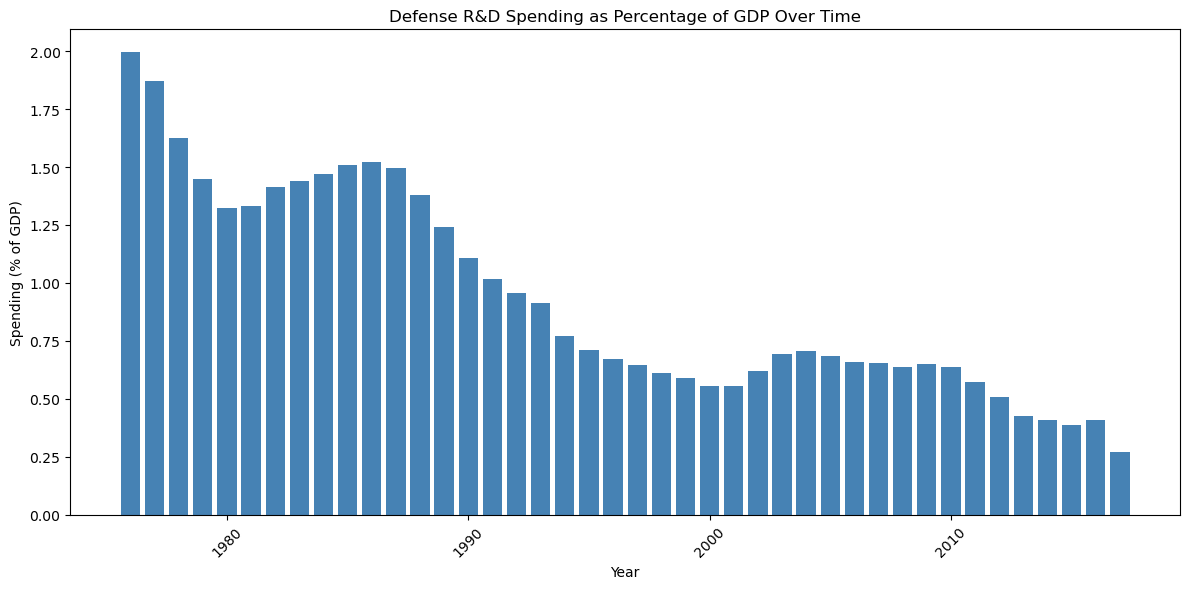

In [ ]:
#1. Filtering on DOD only
dod_df = tidy_df[tidy_df["Department"] == "DOD"].copy()

#2. Computing spending as a percentage of GDP
dod_df["Spending_Pct_GDP"] = dod_df["R&D_Spending"] / dod_df["GDP"] * 100  # multiply by 100 for %

#3. Plotting a bar chart
plt.figure(figsize=(12,6))
plt.bar(dod_df["Year"], dod_df["Spending_Pct_GDP"], color='steelblue')

plt.title("Defense R&D Spending as Percentage of GDP Over Time")
plt.xlabel("Year")
plt.ylabel("Spending (% of GDP)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot shows that although DOD spending has gone up over time, it has actually decreased as a percentage of total GDP

# BUT CLOSE TO 3%???

## 3. Pivot Table

In [38]:
pivot_table_year = pd.pivot_table(tidy_df, values='R&D_Spending',
                                    index='Year', columns='Department', aggfunc='mean'
                                    )

print("\nPivot Table (Department Spending Per Year):")
print(pivot_table_year)


Pivot Table (Department Spending Per Year):
Department           DHS           DOC           DOD           DOE  \
Year                                                                 
1976        0.000000e+00  8.190000e+08  3.569600e+10  1.088200e+10   
1977        0.000000e+00  8.370000e+08  3.796700e+10  1.374100e+10   
1978        0.000000e+00  8.710000e+08  3.702200e+10  1.566300e+10   
1979        0.000000e+00  9.520000e+08  3.717400e+10  1.561200e+10   
1980        0.000000e+00  9.450000e+08  3.700500e+10  1.522600e+10   
1981        0.000000e+00  8.290000e+08  4.173700e+10  1.479800e+10   
1982        0.000000e+00  6.930000e+08  4.689300e+10  1.216000e+10   
1983        0.000000e+00  7.000000e+08  5.100800e+10  1.112900e+10   
1984        0.000000e+00  7.550000e+08  5.813900e+10  1.173100e+10   
1985        0.000000e+00  7.890000e+08  6.441600e+10  1.204300e+10   
1986        0.000000e+00  7.780000e+08  6.893100e+10  1.091100e+10   
1987        0.000000e+00  8.040000e+08  7.154

# Is it ok that this is not displaying full table

This pivot table shows the total spending by department over time.

Next, we can make a pivot table to show how department spending has evolved as a percentage of GDP. 

In [ ]:
#Creating a new column for spending as a pct of GDP
tidy_df["Pct_GDP"] = (tidy_df["R&D_Spending"] / tidy_df["GDP"]) * 100

#Making a table showing spending as a pct of GDP
pct_pivot = tidy_df.pivot_table(
    values="Pct_GDP", index="Year", columns="Department", aggfunc="mean")

print(pct_pivot)

Department       DHS       DOC       DOD       DOE       DOT       EPA  \
Year                                                                     
1976        0.000000  0.045754  1.994190  0.607933  0.063799  0.054078   
1977        0.000000  0.041272  1.872140  0.677564  0.053994  0.047633   
1978        0.000000  0.038235  1.625198  0.687577  0.050746  0.051580   
1979        0.000000  0.037043  1.446459  0.607471  0.039066  0.042879   
1980        0.000000  0.033786  1.323025  0.544369  0.037469  0.032285   
1981        0.000000  0.026418  1.330051  0.471574  0.031166  0.028713   
1982        0.000000  0.020911  1.414997  0.366928  0.021183  0.019342   
1983        0.000000  0.019768  1.440497  0.314290  0.022592  0.014149   
1984        0.000000  0.019099  1.470756  0.296762  0.025753  0.013104   
1985        0.000000  0.018478  1.508571  0.282037  0.020726  0.014403   
1986        0.000000  0.017152  1.519643  0.240542  0.016446  0.014043   
1987        0.000000  0.016813  1.4960